# CORSA: Near-Lossless Image Compression for Sentinel-2 Data


### Overview

With the huge amount of data collected by several Earth observation missions, limitations in downlink capacity and storage have become a major obstacle to fully utilising all the valuable information. The CORSA project, funded by the European Space Agency's PhiLab EO Open Science for Society framework, addresses this challenge through a novel AI-based compression method.

### What is CORSA?

The [CORSA](https://remotesensing.vito.be/services/corsa) is a family of lightweight AI Compression and Foundation Models for Multi- and Hyperspectral Data. It uses advanced deep learning techniques to efficiently compress imagery from sensors like Sentinel-1, Sentinel-2, and PRISMA, drastically reducing data volume while maintaining high image fidelity, even at 100x compression rates. 

CORSA's compressed features can be directly used to build downstream applications such as land-use classification, change detection, and natural disaster mapping. Read more about the CORSA method in this [blog post](https://remotesensing.vito.be//news/corsa-eo-data-compression-and-processing-ai).

### CORSA processes in openEO

The compression service for Sentinel-2 has been implemented in openEO and integrated into the VITO(Terrascope) openEO backend as two processes: `corsa_compress` and `corsa_decompress`. These processes allow users to easily apply the CORSA compression and decompression methods within their openEO workflows, enabling efficient storage and transmission of Sentinel-2 data while maintaining high fidelity for downstream applications.

### In This Notebook
We'll demonstrate the complete CORSA workflow in openEO:

1. Load a Sentinel-2 image from the openEO backend for a specific area and time range
2. Apply the [`corsa_compress`](https://github.com/VITO-RS-CORSA) process to obtain the compressed representation
3. Apply the [`corsa_decompress`](https://docs.openeo.cloud/processes/#corsa_decompress) process to reconstruct the original image
4. Visualise and compare results

For detailed information about the CORSA project, methods, and implementation, see the [CORSA project repository](https://github.com/VITO-RS-CORSA).

#### Step 1: Connect to openEO Backend

First, let's connect to the openEO backend (openeo.vito.be) that has the CORSA processes available.

In [1]:
import openeo
connection = openeo.connect("openeo.terrascope.be").authenticate_oidc()

Authenticated using refresh token.


Let's also check all the CORSA processes offered by the backend.

In [2]:
# Confirm the CORSA processes are available
processes = connection.list_processes()
corsa_procs = [p['id'] for p in processes if 'corsa' in p['id'].lower()]
print("Available CORSA processes:", corsa_procs)

Available CORSA processes: ['corsa_compress', 'corsa_compress_v2', 'corsa_decompress', 'corsa_decompress_v2']


For more details on these processes, refer to the [openEO process documentation](https://docs.openeo.cloud/processes/#corsa_compress), which explains the `corsa_compress` process and its parameters. Alternatively, you can run the code below to retrieve the process description directly from the backend.

In [3]:
connection.describe_process("corsa_compress")

{'description': 'Compresses a data cube by means of the CORSA algorithm.',
 'experimental': True,
 'id': 'corsa_compress',
 'parameters': [{'description': 'a Sentinel 2 data cube with 10 bands that correspond to: "B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B11" and "B12".',
   'name': 'data',
   'optional': False,
   'schema': {'subtype': 'datacube', 'type': 'object'}}],
 'returns': {'description': 'a data cube consisting of two bands: "level_0" and "level_1"',
  'schema': {'subtype': 'datacube', 'type': 'object'}}}

#### Step 2: Load Sentinel-2 Data


Now, let us load the Sentinel-2 L2A collection for our area of interest and time period. We select all 10 spectral bands and apply a cloud-cover filter (<10%) to ensure high-quality spectral observations.

In [4]:
s2_cube = connection.load_collection(
    "SENTINEL2_L2A",
    spatial_extent={"west": 5.107956, "south": 51.263318, "east": 5.225201, "north": 51.302713},
    temporal_extent=["2025-06-12", "2025-06-12"],
    bands=["B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B11", "B12"],
    properties={
        "eo:cloud_cover": lambda v: v <= 10,
    }
)


Furthermore, to efficiently compare the original and reconstructed outputs, let us save intermediate results in a single openEO workflow. This avoids re-running the same processes multiple times. For more information on saving intermediate results in the workflow, please refer to the [openEO documentation](https://openeo.org/documentation/1.0/processes/#save_result).

In [5]:
s2_cube_result =s2_cube.save_result(format="GTiff", options={"filename_prefix": "s2_cube"})

#### Step 3: CORSA compression

Applying corsa_compress to the Sentinel-2 data cube results in a compressed representation that captures the essential spectral and spatial information in a much smaller data size. The CORSA compression process encodes the original 10-band Sentinel-2 image into two levels of latent features:

- **Level 0**: Captures fine-scale spatial features at 20 m resolution, preserving local spectral-spatial detail
- **Level 1**: Captures coarse-scale contextual features at 40 m resolution, storing broader spectral structure and scene context

These two levels together form a compact compressed bitstream that can be efficiently stored and transmitted.

In [6]:
compress_cube = s2_cube.process("corsa_compress", data=s2_cube)

In [7]:
compress_cube_result = compress_cube.save_result(format="GTiff", options={"filename_prefix": "compress_cube"})

Each compression level can be filtered individually for further analysis and processing.
Furthermore, we can directly apply supported openEO processes, such as filter_bands, to the compressed data. This allows us to perform analysis directly on the compressed data without decompressing it first, thereby saving time and computational resources.

In [8]:
level1_cube = compress_cube.process("filter_bands", bands=["level_1"], data=compress_cube)
level1_cube_result = level1_cube.save_result(format="GTiff", options={"filename_prefix": "level1_cube"})

#### Step 4: CORSA decompression

The `corsa_decompress` process reconstructs the full 10-band Sentinel-2 reflectance datacube from the compressed latent representation.


**Note**: While this notebook demonstrates decompression for visualization and comparison purposes, it's important to note that in real-world applications, if you only need the original image, you can simply use the original Sentinel-2 data rather than compressing and then decompressing it. The primary value of CORSA lies in the compressed features themselves. These latent representations are highly effective for downstream tasks such as land-use classification, change detection, etc. 

For detailed examples of how to leverage CORSA's compressed features for these downstream applications, please refer to the [CORSA project repository](https://github.com/VITO-RS-CORSA/CORSA-S2-openEO).

In [9]:
decompress_cube = compress_cube.process("corsa_decompress", data=compress_cube)
decompress_cube_result = decompress_cube.save_result(format="GTiff", options={"filename_prefix": "decompress_cube"})

Finally, let us save and download all the results in a single openeo job. The saved results include the original image, the compressed representation, the compressed level1 data, and the decompressed image. This allows us to compare the original and decompressed images.


| Output file prefix | Content                                            | Purpose                          |
| ------------------ | -------------------------------------------------- | -------------------------------- |
| `s2_cube`          | S2 L2A image                                       | Reference data                   |
| `compress_cube`    | CORSA level_0 latent(20m) and level_1 latent (40m) | Corsa Compressed                 |
| `level1_cube`      | Level1 (40m)                                       | Coarse Compressed Feature               |
| `decompress_cube`  | CORSA-decompressed reflectance                     | Round-trip output for comparison |

For more details on managing multiple results, refer to the [openEO MultiResult documentation](https://open-eo.github.io/openeo-python-client/api.html#openeo.rest.multiresult.MultiResult).

In [10]:
multi_result = openeo.MultiResult(
        [s2_cube_result, compress_cube_result, level1_cube_result, decompress_cube_result]
    )

In [11]:
corsa_job = multi_result.create_job(
                        title="CORSA process in openEO", 
                        description="CORSA compression and decompression processes offered by the VITO openeo backend",
                        )
corsa_job.start_and_wait()

0:00:00 Job 'j-2606281316134a989c980c50cfdbd029': send 'start'
0:00:16 Job 'j-2606281316134a989c980c50cfdbd029': queued (progress 0%)
0:00:21 Job 'j-2606281316134a989c980c50cfdbd029': queued (progress 0%)
0:00:32 Job 'j-2606281316134a989c980c50cfdbd029': running (progress 2.9%)
0:00:40 Job 'j-2606281316134a989c980c50cfdbd029': running (progress 4.1%)
0:00:50 Job 'j-2606281316134a989c980c50cfdbd029': running (progress 5.7%)
0:01:02 Job 'j-2606281316134a989c980c50cfdbd029': running (progress 7.5%)
0:01:19 Job 'j-2606281316134a989c980c50cfdbd029': running (progress 9.9%)
0:01:41 Job 'j-2606281316134a989c980c50cfdbd029': running (progress 12.7%)
0:02:05 Job 'j-2606281316134a989c980c50cfdbd029': running (progress 15.7%)
0:02:35 Job 'j-2606281316134a989c980c50cfdbd029': finished (progress 100%)


<BatchJob job_id='j-2606281316134a989c980c50cfdbd029'>

In [12]:
result = corsa_job.get_results()
result.download_files("corsa/")

[PosixPath('corsa/compress_cube_2025-06-12Z.tif'),
 PosixPath('corsa/decompress_cube_2025-06-12Z.tif'),
 PosixPath('corsa/level1_cube_2025-06-12Z.tif'),
 PosixPath('corsa/s2_cube_2025-06-12Z.tif'),
 PosixPath('corsa/job-results.json')]

### Plot the results

In [13]:
import rasterio
import matplotlib.pyplot as plt

In [14]:
original = rasterio.open("corsa/s2_cube_2025-06-12Z.tif").read()
compressed = rasterio.open("corsa/compress_cube_2025-06-12Z.tif").read()
decompressed = rasterio.open("corsa/decompress_cube_2025-06-12Z.tif").read()
level1_cube = rasterio.open("corsa/level1_cube_2025-06-12Z.tif").read()

# print shapes
print("Original shape:", original.shape)
print("Compressed shape:", compressed.shape)
print("Decompressed shape:", decompressed.shape)
print("Level 1 shape:", level1_cube.shape)

Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.


Original shape: (10, 463, 831)
Compressed shape: (2, 232, 416)
Decompressed shape: (10, 463, 831)
Level 1 shape: (1, 232, 416)


In [15]:
import numpy as np
import matplotlib.pyplot as plt


RGB_BANDS = (2, 1, 0)  # B04=R, B03=G, B02=B

def to_rgb(arr, bands=RGB_BANDS, p_low=2, p_high=98):
    """Extract and percentile-stretch an RGB chip from a (C, H, W) array."""
    rgb = arr[list(bands)].astype("float32")          
    rgb = np.moveaxis(rgb, 0, -1)                     
    lo, hi = np.percentile(rgb, [p_low, p_high])
    rgb = (rgb - lo) / (hi - lo + 1e-6)
    return np.clip(rgb, 0, 1)

def plot_results(imgs, titles, cmaps=None):
    """imgs: list of (H,W,3) or (H,W) arrays, already scaled to [0,1]"""
    cmaps = cmaps or ["viridis"] * 3
    fig, axes = plt.subplots(1, 3, figsize=(12, 20),dpi=300)
    for ax, img, title, cmap in zip(axes, imgs, titles, cmaps):
        ax.imshow(img, cmap=cmap)
        ax.set_title(title)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


By downloading the original Sentinel-2 images, we can compare them with the compressed images.


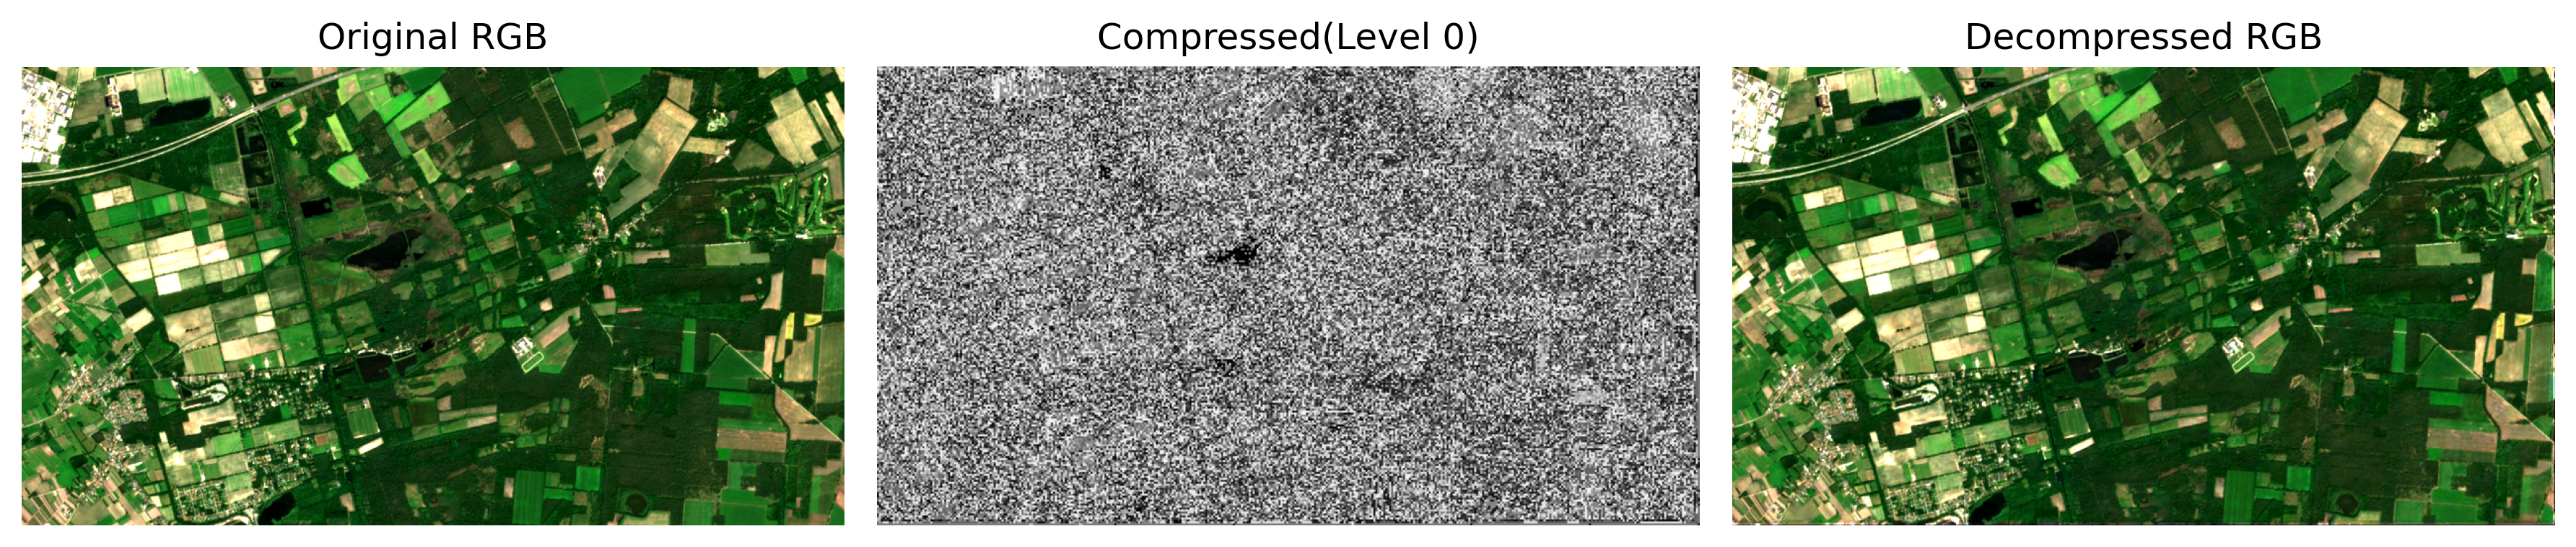

In [16]:
plot_results([to_rgb(original), compressed[0], to_rgb(decompressed)],
       ["Original RGB", "Compressed(Level 0)", "Decompressed RGB"],
       cmaps=[None, "gray", None])



The reconstructed image closely resembles the original input, demonstrating the near-lossless nature of the CORSA compression method. The reconstructed data can then be used for various downstream applications, such as land cover classification, vegetation monitoring, or change detection, without significant loss of information compared to the original Sentinel-2 data.

Moreover, histograms of pixel values for each band provide a quantitative measure of similarity between original and decompressed images. Comparing the histograms visually reveals any significant differences in spectral distribution across bands.

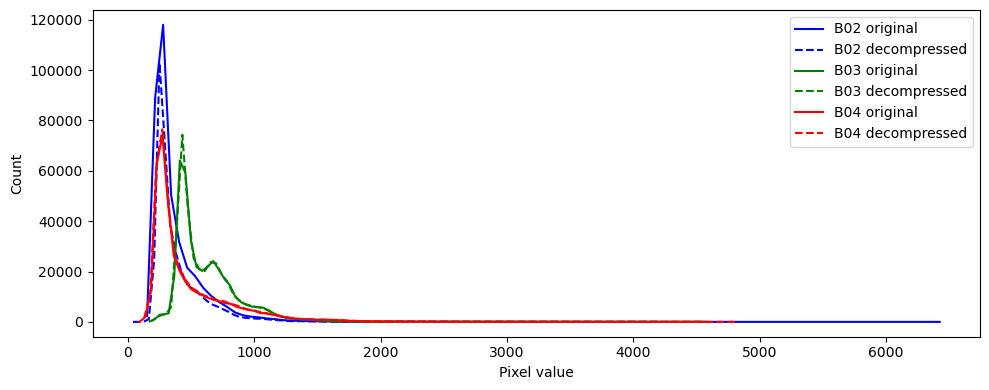

In [17]:
colors = {"B02": "blue", "B03": "green", "B04": "red"}

fig, ax = plt.subplots(figsize=(10, 4))

for idx, (name, color) in enumerate(colors.items()):
    counts, bins = np.histogram(original[idx].ravel(), bins=100)
    ax.plot(bins[:-1], counts, color=color, linestyle="-",  label=f"{name} original")
    counts, bins = np.histogram(decompressed[idx].ravel(), bins=100)
    ax.plot(bins[:-1], counts, color=color, linestyle="--", label=f"{name} decompressed")

ax.set_xlabel("Pixel value")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

Let's examine the compression ratio achieved by CORSA:

In [18]:
# Calculate compression ratio
import os

original_size = os.path.getsize("corsa/s2_cube_2025-06-12Z.tif")
compressed_size = os.path.getsize("corsa/compress_cube_2025-06-12Z.tif")
decompressed_size = os.path.getsize("corsa/decompress_cube_2025-06-12Z.tif")

print(f"Original size (S2 L2A):      {round(original_size/1024/1024, 2)} MB")
print(f"Compressed size (CORSA):     {round(compressed_size/1024/1024, 2)} MB")
compression_ratio = original_size / compressed_size
print(f"Compression ratio:           {round(compression_ratio, 2)}x smaller")


Original size (S2 L2A):      3.45 MB
Compressed size (CORSA):     0.14 MB
Compression ratio:           24.92x smaller


This notebook covered a very simple use case of using the CORSA processes in an openEO workflow. For a more detailed use case and analysis of the CORSA method, please refer to the [CORSA project repository](https://github.com/VITO-RS-CORSA/CORSA-S2-openEO)